In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv("result.csv")
df.head()

,id,img_name,shape,center,radius,color,thickness,filled,box_corner,box_length,box_width
0,1,img1.png,circle,"(403, 364)",66,"(0.36470588235294116, 0.9450980392156862, 0.80...",6,False,"(334, 295)",138,138
1,2,img2.png,circle,"(156, 394)",107,"(0.15294117647058825, 0.7568627450980392, 0.84...",10,False,"(44, 282)",224,224
2,3,img3.png,circle,"(424, 404)",52,"(0.8549019607843137, 0.4549019607843137, 0.905...",1,False,"(372, 352)",105,105
3,4,img4.png,circle,"(328, 368)",45,"(0.21568627450980393, 0.7098039215686275, 0.62...",7,False,"(280, 320)",97,97
4,5,img5.png,circle,"(444, 419)",52,"(0.6078431372549019, 0.3764705882352941, 0.549...",2,False,"(391, 366)",106,106


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20100 non-null  int64 
 1   img_name    20100 non-null  object
 2   shape       20100 non-null  object
 3   center      20100 non-null  object
 4   radius      20100 non-null  int64 
 5   color       20100 non-null  object
 6   thickness   20100 non-null  int64 
 7   filled      20100 non-null  bool  
 8   box_corner  20100 non-null  object
 9   box_length  20100 non-null  int64 
 10  box_width   20100 non-null  int64 
dtypes: bool(1), int64(5), object(5)
memory usage: 1.6+ MB


In [4]:
df.isnull().sum()

id            0
img_name      0
shape         0
center        0
radius        0
color         0
thickness     0
filled        0
box_corner    0
box_length    0
box_width     0
dtype: int64

In [5]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
20095    False
20096    False
20097    False
20098    False
20099    False
Length: 20100, dtype: bool

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          20100 non-null  int64 
 1   img_name    20100 non-null  object
 2   shape       20100 non-null  object
 3   center      20100 non-null  object
 4   radius      20100 non-null  int64 
 5   color       20100 non-null  object
 6   thickness   20100 non-null  int64 
 7   filled      20100 non-null  bool  
 8   box_corner  20100 non-null  object
 9   box_length  20100 non-null  int64 
 10  box_width   20100 non-null  int64 
dtypes: bool(1), int64(5), object(5)
memory usage: 1.6+ MB


In [7]:
df.columns

Index(['id', 'img_name', 'shape', 'center', 'radius', 'color', 'thickness',
       'filled', 'box_corner', 'box_length', 'box_width'],
      dtype='object')

In [8]:
X = df.drop(['shape', 'img_name', 'id'], axis=1) # Feature
y = df['shape'] # Target

In [9]:
import ast

def split_tuple(col):
    values = col.apply(ast.literal_eval)
    return values.apply(lambda x: x[0]), values.apply(lambda x: x[1])

X['center_x'], X['center_y'] = split_tuple(X['center'])
X['box_x'], X['box_y'] = split_tuple(X['box_corner'])

X.drop(['center', 'box_corner'], axis=1, inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder

X['color'] = LabelEncoder().fit_transform(X['color'])
X['filled'] = LabelEncoder().fit_transform(X['filled'])

In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

le_shape = LabelEncoder()
y_encoded = le_shape.fit_transform(y)

y_categorical = to_categorical(y_encoded)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(y_train.shape[1], activation='softmax')
])

C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30


C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(32, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


394/402 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0000e+00

C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\losses\losses.py:33: SyntaxWarning: In loss categorical_crossentropy, expected y_pred.shape to be (batch_size, num_classes) with num_classes > 1. Received: y_pred.shape=(None, 1). Consider using 'binary_crossentropy' if you only have 2 classes.
  return self.fn(y_true, y_pred, **self._fn_kwargs)


402/402 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/30
402/402 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accur

In [17]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Test Accuracy: 1.0


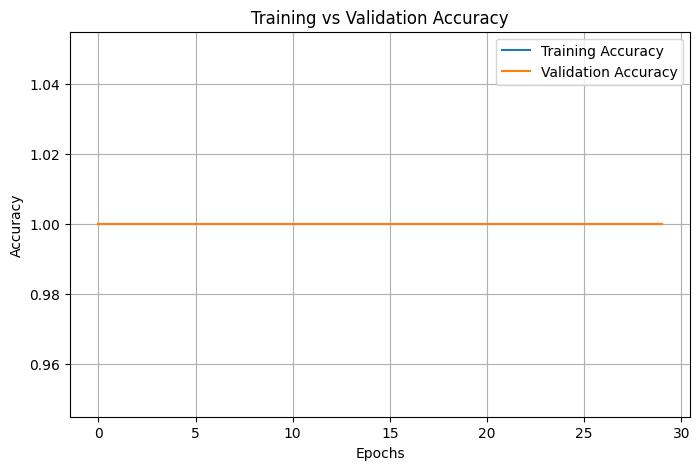

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

In [19]:
FEATURE_COLUMNS = [
    'radius', 'color', 'thickness', 'filled',
    'box_length', 'box_width',
    'center_x', 'center_y',
    'box_x', 'box_y']

In [20]:
new_input = {
    'radius': 28,
    'color': 'red',
    'thickness': 3,
    'filled': True,
    'box_length': 55,
    'box_width': 55,
    'center_x': 120,
    'center_y': 210,
    'box_x': 95,
    'box_y': 180}

In [21]:
import pandas as pd

new_df = pd.DataFrame([new_input])
new_df = new_df[FEATURE_COLUMNS]  # enforce correct column order

In [22]:
# Assuming you have categorical columns that need encoding
from sklearn.preprocessing import LabelEncoder

# Create a copy to avoid modifying original
new_df_encoded = new_df.copy()

# Encode categorical columns (replace 'column_name' with your actual column names)
le = LabelEncoder()
for col in new_df_encoded.select_dtypes(include=['object']).columns:
    new_df_encoded[col] = le.fit_transform(new_df_encoded[col])

# Now scale
new_scaled = scaler.transform(new_df_encoded)

In [23]:
import numpy as np

probs = model.predict(new_scaled)
predicted_index = np.argmax(probs, axis=1)
predicted_shape = le_shape.inverse_transform(predicted_index)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step


C:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\ops\nn.py:946: UserWarning: You are using a softmax over axis -1 of a tensor of shape (1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [24]:
print("Predicted Shape:", predicted_shape[0])

Predicted Shape: circle
